## Masked Autoencoders: Visualization Demo

This is a visualization demo using our pre-trained MAE models. No GPU is needed.

In [1]:
import sys
import os

import torch
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
sys.path.append("..")
import models_mae_gray
sys.path.append("bigclassroom")

### Define utils

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.metrics import structural_similarity as compare_ssim
from matplotlib.colors import Normalize, LogNorm
from scipy.interpolate import interp1d
import pandas as pd
from scipy.ndimage import zoom

def prepare_model(chkpt_dir, arch='mae_vit_large_patch16'):
    # Build model and load checkpoint
    model = getattr(models_mae_gray, arch)()
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def show_image(image, title, mask=None):
    # 將數據進行反正則化
    image_normalized = inverse_normalize(image)
    cbar_ticks = np.linspace(300, 1600, 5)  # 動態生成色條刻度

    # 繪製熱圖
    img = plt.imshow(image_normalized, cmap='hot', norm=Normalize(vmin=300, vmax=1600))
    plt.title(title, pad=20)  # 調整標題與圖像的距離

    # 添加色條
    cbar = plt.colorbar(img, label='PPM')
    cbar.set_ticks(cbar_ticks)  # 使用等分刻度
    cbar.ax.set_yticklabels([f"{tick:.0f}" for tick in cbar_ticks])  # 整數標籤

    # 設置 Y 軸和 X 軸刻度
    plt.yticks([0, 1, 2, 3], labels=[0, 1, 2, 3])
    ax = plt.gca()
    ax.xaxis.set_ticks_position('top')  # X 軸刻度移到頂部
    ax.xaxis.set_label_position('top')
    plt.xticks([0, 1, 2, 3], labels=[0, 1, 2, 3])

    # 显示每个像素的值
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # 反正则化数据
            original_value = inverse_normalize(image[i, j])
            if mask is not None and mask[i, j] == 0:  # 掩码为 0 的地方
                value = round(original_value)  # 四舍五入为整数
                plt.text(j, i, f"{value}", ha='center', va='center', color='white', fontsize=12)
            elif mask is None:
                value = f"{original_value:.2f}"  # 保留两位小数
                plt.text(j, i, value, ha='center', va='center', color='white', fontsize=12)

    # 添加掩碼覆蓋層
    if mask is not None:
        gray_overlay = np.ones_like(image) * 0.5
        overlay = np.ma.masked_where(mask == 0, gray_overlay)
        plt.imshow(overlay, cmap='gray', norm=Normalize(vmin=0, vmax=1), alpha=1.0)

    plt.show()


def show_image_original(image, title, mask=None):
    # 與 show_image 基本一致，但保留原始像素值的兩位小數顯示
    image_normalized = inverse_normalize(image)
    cbar_ticks = np.linspace(300, 1600, 5)

    img = plt.imshow(image_normalized, cmap='hot', norm=Normalize(vmin=300, vmax=1600))
    plt.title(title, pad=20)

    cbar = plt.colorbar(img, label='PPM')
    cbar.set_ticks(cbar_ticks)
    cbar.ax.set_yticklabels([f"{tick:.0f}" for tick in cbar_ticks])

    plt.yticks([0, 1, 2, 3], labels=[0, 1, 2, 3])
    ax = plt.gca()
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.xticks([0, 1, 2, 3], labels=[0, 1, 2, 3])

    # 显示每个像素的值
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # 反正则化数据
            original_value = inverse_normalize(image[i, j])
            if mask is not None and mask[i, j] == 0:
                value = round(original_value)  # 掩码为 0 的地方四舍五入为整数
                value = f"{value:.0f}"
                plt.text(j, i, value, ha='center', va='center', color='white', fontsize=12)
            else:
                value = round(original_value)  # 掩码为 0 的地方四舍五入为整数
                value = f"{value:.0f}"
                plt.text(j, i, value, ha='center', va='center', color='white', fontsize=12)

    if mask is not None:
        gray_overlay = np.ones_like(image) * 0.5
        overlay = np.ma.masked_where(mask == 0, gray_overlay)
        plt.imshow(overlay, cmap='gray', norm=Normalize(vmin=0, vmax=1), alpha=1.0)

    plt.show()

def show_image_mask(image, title, mask=None):
    # 與前兩個函數一致，強調掩碼區域的處理
    image_normalized = inverse_normalize(image)
    cbar_ticks = np.linspace(300, 1600, 5)

    img = plt.imshow(image_normalized, cmap='hot', norm=Normalize(vmin=300, vmax=1600))
    plt.title(title, pad=20)

    cbar = plt.colorbar(img, label='PPM')
    cbar.set_ticks(cbar_ticks)
    cbar.ax.set_yticklabels([f"{tick:.0f}" for tick in cbar_ticks])

    plt.yticks([0, 1, 2, 3], labels=[0, 1, 2, 3])
    ax = plt.gca()
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.xticks([0, 1, 2, 3], labels=[0, 1, 2, 3])
    # 显示每个像素的值
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # 反正则化数据
            original_value = inverse_normalize(image[i, j])
            if mask is not None and mask[i, j] == 0:
                value = round(original_value)  # 掩码为 0 的地方四舍五入为整数
                plt.text(j, i, value, ha='center', va='center', color='white', fontsize=12)
            else:
                value = f"{original_value:.2f}"  # 其余地方保留两位小数

    if mask is not None:
        gray_overlay = np.ones_like(image) * 0.5
        overlay = np.ma.masked_where(mask == 0, gray_overlay)
        plt.imshow(overlay, cmap='gray', norm=Normalize(vmin=0, vmax=1), alpha=1.0)

    plt.show()


def show_image_inter(image, title, mask=None):
    # Perform interpolation (zoom)
    zoomed_image = zoom(image, (180/4, 90/4), order=3)  # 使用三次插值進行放大

    # Display the zoomed image using the 'hot' colormap
    plt.imshow(zoomed_image, cmap='hot', norm=Normalize(vmin=0, vmax=1))
    plt.title(title)
    # 添加 colorbar
    cbar = plt.colorbar()
    # 自定義 colorbar 的刻度和標籤
    cbar.set_ticks(np.linspace(0, 1, num=6))  # 刻度仍然基於 0~1
    cbar.ax.set_yticklabels([f'{int(x)}' for x in np.linspace(300, 1600, num=6)])  # 將顯示標籤改為 300~1600
    plt.xlabel('X Axis')
    plt.ylabel('Y Axis')

    # If a mask is provided, overlay gray on the masked areas
    if mask is not None:
        # Apply the same zoom to the mask
        zoomed_mask = zoom(mask, (180/4, 90/4), order=0)  # 使用最近鄰插值放大 Mask
        gray_overlay = np.ones_like(zoomed_image) * 0.5  # Create a gray overlay
        overlay = np.ma.masked_where(zoomed_mask == 0, gray_overlay)  # Mask out non-masked areas
        plt.imshow(overlay, cmap='gray', norm=Normalize(vmin=0, vmax=1), alpha=1.0)  # Overlay with gray

def inverse_normalize(log_normalized_values):
    # 將 0~1 的正規化數據反轉回 log 範圍，然後再轉回線性空間的原始範圍
    original_min = 300
    original_max = 1600
    log_values = log_normalized_values * (np.log(original_max) - np.log(original_min)) + np.log(original_min)
    original_values = np.exp(log_values)
    return original_values

def run_one_image(img, x_original, model, mask_ratio, custom_mask=None):
    img = img.values.astype('float32')
    x = torch.tensor(img).unsqueeze(0).unsqueeze(1)

    # Run MAE
    loss, y, mask = model(x.float(), mask_ratio=mask_ratio, custom_mask=custom_mask)
    print(loss)

    y = model.unpatchify(y).detach().cpu()

    # Visualize mask
    mask = mask.detach()
    mask = mask.unsqueeze(-1).repeat(1, 1, model.patch_embed.patch_size[0]**2)
    mask = model.unpatchify(mask).detach().cpu()

    # Masked image
    im_masked = x * (1 - mask)

    # MAE reconstructed image
    im_paste = x * (1 - mask) + y * mask

    # Convert tensors to numpy arrays for visualization (before log transformation)
    x_original_np = np.flipud(x.squeeze().detach().cpu().numpy())
    im_masked_np = im_masked.squeeze().detach().cpu().numpy()
    im_paste_np = np.flipud(im_paste.squeeze().detach().cpu().numpy())

    # Directly set the masked areas to gray in im_masked_np
    im_masked_np[mask.squeeze().cpu().numpy() == 1] = 0.5  # 灰色值為 0.5
    im_masked_np = np.flipud(im_masked_np)

    # Flatten images for inverse transformation
    im_paste_flat = im_paste.flatten().detach().numpy()
    x_flat = x.flatten().detach().numpy()

    # Inverse normalization to recover original values
    im_paste_original = inverse_normalize(im_paste_flat)
    x_original = inverse_normalize(x_flat)

    # Reshape to original dimensions
    x_original = x_original.reshape(4, 4)
    im_paste_original = im_paste_original.reshape(4, 4)
    x_original = np.flipud(x_original)
    im_paste_original = np.flipud(im_paste_original)
    print('original')
    print(x_original)
    print('prediction')
    print(im_paste_original)
    # 計算相對誤差並打印
    relative_error = np.abs((x_original - im_paste_original) / x_original)
    max_error = np.max(relative_error)
    non_zero_relative_error = relative_error[relative_error > 0]
    min_error = np.min(non_zero_relative_error) if non_zero_relative_error.size > 0 else 0
    mean_error = np.mean(non_zero_relative_error) if non_zero_relative_error.size > 0 else 0

    print(f"Relative error max: {max_error}")
    print(f"Relative error min (non-zero): {min_error}")
    print(f"Relative error mean (non-zero): {mean_error}")
    print('relative error')
    print(relative_error)
    # 計算均方根誤差並打印
    mse = (x_original - im_paste_original) ** 2
    rmse = np.sqrt(mse)

    max_rmse = np.max(rmse)
    non_zero_rmse = rmse[rmse > 0]
    min_rmse = np.min(non_zero_rmse) if non_zero_rmse.size > 0 else 0
    mean_rmse = np.mean(non_zero_rmse) if non_zero_rmse.size > 0 else 0

    print(f"Root mean square error max: {max_rmse}")
    print(f"Root mean square error min (non-zero): {min_rmse}")
    print(f"Root mean square error mean (non-zero): {mean_rmse}")

    # 顯示圖像 (在 LOG 轉換之前)
    # plt.figure(figsize=(12, 6))
    # plt.subplot(1, 3, 1)
    # show_image(x_original_np, "Original")
    # plt.subplot(1, 3, 2)
    # show_image(x_original_np, "Masked", np.flipud(mask.squeeze().cpu().numpy()))
    # plt.subplot(1, 3, 3)
    # show_image(im_paste_np, "Prediction")
    # plt.show()

    # # 顯示圖像 (在 LOG 轉換之前)
    plt.figure(figsize=(12, 6))
    show_image_original(x_original_np, "Original")
    plt.show()
    plt.figure(figsize=(12, 6))
    show_image_mask(x_original_np, "Masked", np.flipud(mask.squeeze().cpu().numpy()))
    plt.show()
    plt.figure(figsize=(12, 6))
    show_image(im_paste_np, "Prediction")
    plt.show()

    

    # 顯示相對誤差和均方誤差矩陣
    show_relative_error_matrix(relative_error)
    show_mse_matrix(rmse)
    # 插值 (使用三次樣條插值)
    x_original_interp = zoom(x_original_np, (90/4, 180/4), order=3)  # 將 4x4 插值為 90x180
    im_paste_interp = zoom(im_paste_np, (90/4, 180/4), order=3)


    # 定義等高線級別
    levels = np.linspace(0, 1, 30)  # 正規化範圍
    inverse_levels = inverse_normalize(levels)  # 將正規化範圍轉回原始數值

    # 設定等高線級別（原始數據範圍）
    levels = np.linspace(300, 1600, 30)
    cbar_ticks = np.linspace(300, 1600, 5)

    # 將正規化數據轉換為原始數據範圍
    x_original_interp_normalized = inverse_normalize(x_original_interp)
    im_paste_interp_normalized = inverse_normalize(im_paste_interp)

    # 繪製原始數據的熱圖和等高線
    plt.figure(figsize=(12, 6))
    img1 = plt.imshow(x_original_interp_normalized, cmap='hot', extent=[0, 9, 0, 18], vmin=300, vmax=1600)
    cbar1 = plt.colorbar(img1, label='PPM')
    cbar1.set_ticks(cbar_ticks)
    contour1 = plt.contour(x_original_interp_normalized, levels=levels, colors='white', linewidths=0.5, extent=[0, 9, 0, 18])
    plt.clabel(contour1, inline=True, fontsize=12, fmt="%.0f")  # 標注原始數據值
    plt.title('Original')
    plt.xlabel('X Axis')
    plt.ylabel('Y Axis')
    plt.xlim(0, 9)
    plt.ylim(0, 18)
    plt.tight_layout()
    plt.show()

    # 繪製預測數據的熱圖和等高線
    plt.figure(figsize=(12, 6))
    img2 = plt.imshow(im_paste_interp_normalized, cmap='hot', extent=[0, 9, 0, 18], vmin=300, vmax=1600)
    cbar2 = plt.colorbar(img2, label='PPM')
    cbar2.set_ticks(cbar_ticks)  # 原始數據的範圍
    contour2 = plt.contour(im_paste_interp_normalized, levels=levels, colors='white', linewidths=0.5, extent=[0, 9, 0, 18])
    plt.clabel(contour2, inline=True, fontsize=12, fmt="%.0f")  # 標注原始數據值
    plt.title('Prediction')
    plt.xlabel('X Axis')
    plt.ylabel('Y Axis')
    plt.xlim(0, 9)
    plt.ylim(0, 18)
    plt.tight_layout()
    plt.show()

def show_relative_error_matrix(relative_error):
    # Convert relative error to percentage
    relative_error_percent = relative_error * 100

    # Clip values to max 10% for visualization
    relative_error_percent_clipped = np.clip(relative_error_percent, 0, 10)

    # Set up the figure
    fig, ax = plt.subplots()
    cax = ax.matshow(relative_error_percent_clipped, cmap='Blues', vmin=0, vmax=10)

    # Add color bar
    plt.colorbar(cax, label="Relative Error (%)")

    # Display percentage values within each cell (skip 0 values)
    for (i, j), val in np.ndenumerate(relative_error_percent):
        if val != 0:  # Skip zero values
            ax.text(j, i, f"{val:.2f}%", ha='center', va='center', color="black")

    ax.set_title("Relative Error (%)")
    plt.show()

def show_mse_matrix(mse):
    # 設定 vmin 和 vmax 為 MSE 矩陣的最小值和最大值
    vmin = np.min(mse)
    vmax = np.max(mse)

    # Set up the figure
    fig, ax = plt.subplots()
    cax = ax.matshow(mse, cmap='Greens', vmin=vmin, vmax=vmax)

    # Add color bar
    plt.colorbar(cax, label="Root Mean Square Error")

    # Display MSE values within each cell (skip 0 values)
    for (i, j), val in np.ndenumerate(mse):
        if val != 0:  # Skip zero values
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', color="black")

    ax.set_title("Root Mean Square Error")
    plt.show()

### Load a pre-trained MAE model

In [15]:
# This is an MAE model trained with pixels as targets for visualization (ViT-Large, training mask ratio=0.75)

# chkpt_dir = 'cfd_hv-hc_output_dir/checkpoint-2999.pth'
# chkpt_dir = 'finetune_all-hv-hc_output_dir/checkpoint-2999.pth'
# chkpt_dir = 'finetune_hv-hc_output_dir/checkpoint-999.pth'
# chkpt_dir = 'cfd_output_dir/checkpoint-6600.pth'

# chkpt_dir = 'finetune_hv-hc-5-sample-rate_output_dir/checkpoint-4999.pth'
# chkpt_dir = 'finetune_hv-hc-15-sample-rate_output_dir/checkpoint-4999.pth'
# chkpt_dir = 'finetune_hv-hc-30-sample-rate_output_dir/checkpoint-4999.pth'
chkpt_dir = 'finetune_hv-hc-60-sample-rate_output_dir/checkpoint-4999.pth'

model_mae_gray = prepare_model(chkpt_dir, 'mae_vit_base_patch1')
print('Model loaded.')


<All keys matched successfully>
Model loaded.


In [165]:
import torch
import torchvision.models as models

params = model_mae_gray.parameters()

total_params = sum(p.numel() for p in model_mae_gray.parameters())
print(f"Total parameters: {total_params}")

model_size = sum(p.numel() * p.element_size() for p in model_mae_gray.parameters()) / (1024 ** 2)
print(f"Model size: {model_size:.2f} MB")

Total parameters: 110694913
Model size: 422.27 MB


### Run MAE on the image

In [14]:
# custom_mask = torch.tensor([1,1,0,1,1,1,1,1,1], dtype=torch.int)

# custom_mask = torch.tensor([1,1,1,1,0,1,1,1,0,1,1,1,1,0,1,1], dtype=torch.int) # 5
# custom_mask = torch.tensor([1,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1], dtype=torch.int) # 15

custom_mask = torch.tensor([1,1,0,1,0,1,1,1,0,1,1,1,1,1,1,0], dtype=torch.int) # 60


### Load an image

In [5]:

# data = pd.read_csv('1104-1in3out-lv-hc_dataset/test/3330.csv', header=None, index_col=False)
# data = pd.read_csv('1104-1in3out-lv-hc_dataset/test/3430.csv', header=None, index_col=False)
# data = pd.read_csv('1104-1in3out-lv-hc_dataset/test/3530.csv', header=None, index_col=False)

# data = pd.read_csv('1101-1in3out-hv-hc_dataset/test/3330.csv', header=None, index_col=False)
# data = pd.read_csv('1101-1in3out-hv-hc_dataset/test/3430.csv', header=None, index_col=False)
# data = pd.read_csv('1101-1in3out-hv-hc_dataset/test/3530.csv', header=None, index_col=False)

# data = pd.read_csv('1104-1in3out-hv-lc_dataset/test/3330.csv', header=None, index_col=False)
# data = pd.read_csv('1104-1in3out-hv-lc_dataset/test/3430.csv', header=None, index_col=False)
# data = pd.read_csv('1104-1in3out-hv-lc_dataset/test/3530.csv', header=None, index_col=False)

# data = pd.read_csv('1105-1in3out-lv-lc_dataset/test/3330.csv', header=None, index_col=False)
# data = pd.read_csv('1105-1in3out-lv-lc_dataset/test/3430.csv', header=None, index_col=False)
# data = pd.read_csv('1105-1in3out-lv-lc_dataset/test/3530.csv', header=None, index_col=False)

# data = pd.read_csv('1111-1in3out-hv-hc-mid_dataset/test/3330.csv', header=None, index_col=False)
# data = pd.read_csv('1111-1in3out-hv-hc-mid_dataset/test/3430.csv', header=None, index_col=False)
# data = pd.read_csv('1111-1in3out-hv-hc-mid_dataset/test/3530.csv', header=None, index_col=False)

# data = pd.read_csv('1111-1in3out-hv-lc-mid_dataset/test/3330.csv', header=None, index_col=False)
# data = pd.read_csv('1111-1in3out-hv-lc-mid_dataset/test/3430.csv', header=None, index_col=False)
# data = pd.read_csv('1111-1in3out-hv-lc-mid_dataset/test/3530.csv', header=None, index_col=False)

# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_1000.csv', header=None, index_col=False)
# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_2000.csv', header=None, index_col=False)
# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_3000.csv', header=None, index_col=False)

# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_700.csv', header=None, index_col=False)
# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_1400.csv', header=None, index_col=False)
# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_2100.csv', header=None, index_col=False)
# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_2800.csv', header=None, index_col=False)
# data = pd.read_csv('fundamental_dataset/test/1119-1in3out-mv-mc-mid_3500.csv', header=None, index_col=False)

data = pd.read_csv('cfd_hv-hc_dataset/exp_test/1111-1in3out-hv-hc-mid_3000.csv', header=None, index_col=False)

print(data)


          0         1         2         3
0  0.539355  0.540162  0.580678  0.579169
1  0.640143  0.591872  0.594822  0.529588
2  0.746095  0.622144  0.525471  0.515473
3  0.602134  0.532862  0.521326  0.612937


MAE with pixel reconstruction:
tensor(0.0005, grad_fn=<DivBackward0>)
original
[[ 822.00006  731.9999   717.99994  837.     ]
 [1046.0001   850.       723.00006  710.99994]
 [ 876.0002   807.9999   812.0002   727.99994]
 [ 740.00006  741.00006  793.       790.9999 ]]
prediction
[[ 786.0732   736.2317   713.9468   837.     ]
 [1046.0001   776.4729   726.0769   704.88684]
 [ 876.0002   767.3283   766.6718   734.9588 ]
 [ 745.3731   747.4966   793.       767.0251 ]]
Relative error max: 0.08650247007608414
Relative error min (non-zero): 0.004255661275237799
Relative error mean (non-zero): 0.02637871541082859
relative error
[[0.04370666 0.00578116 0.00564507 0.        ]
 [0.         0.08650247 0.00425566 0.00859789]
 [0.         0.05033611 0.0558231  0.00955888]
 [0.00726087 0.00876723 0.         0.03030948]]
Root mean square error max: 73.527099609375
Root mean square error min (non-zero): 3.07684326171875
Root mean square error mean (non-zero): 21.311004638671875


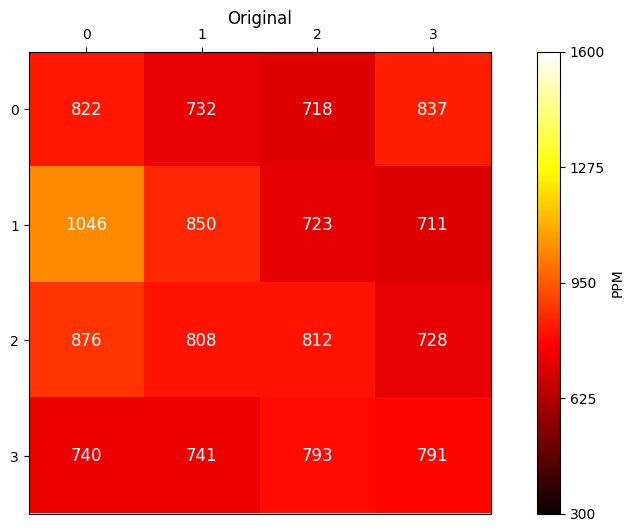

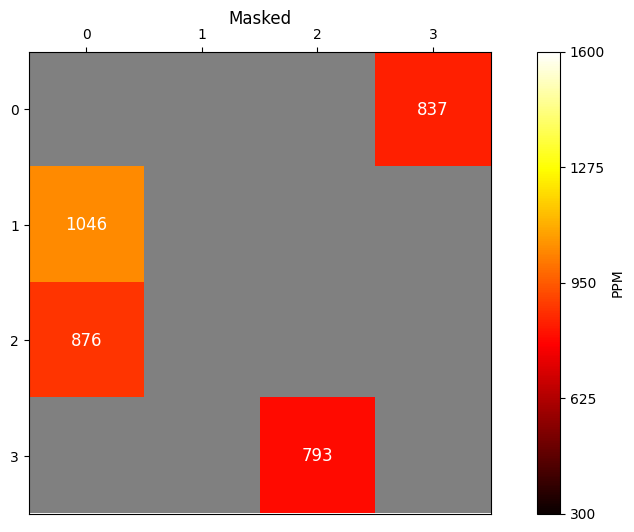

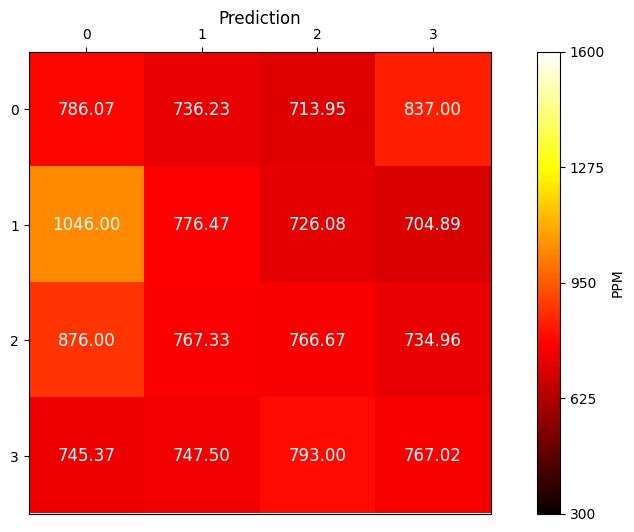

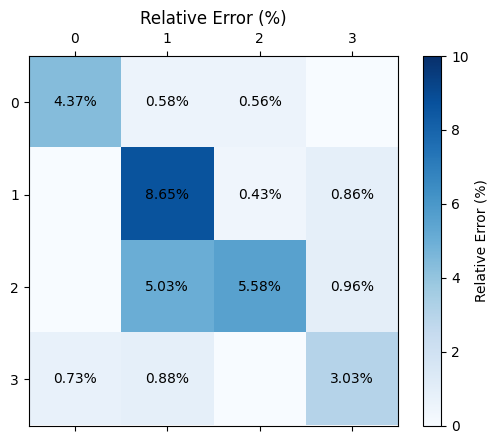

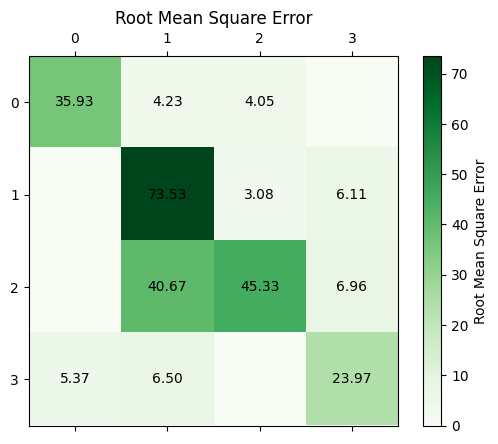

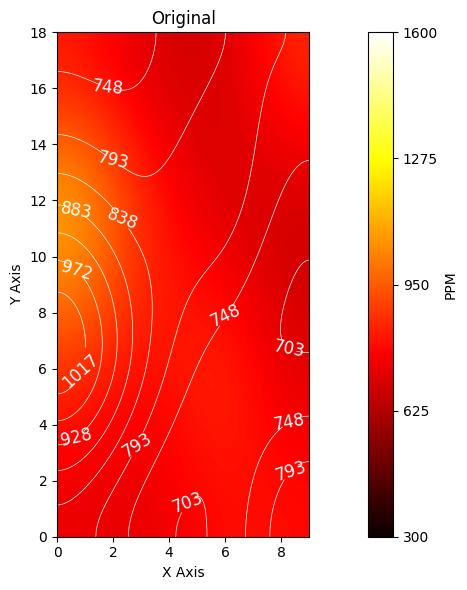

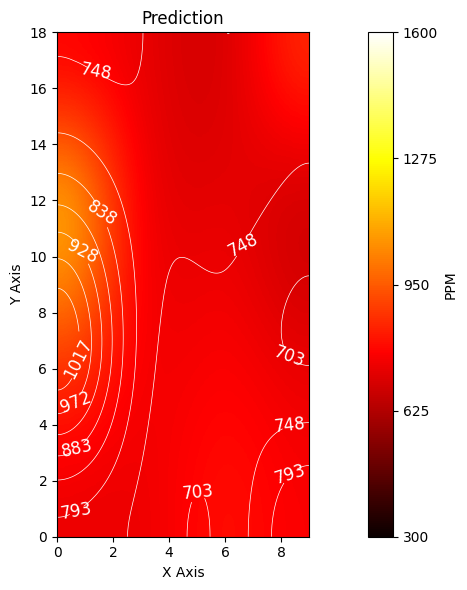

In [16]:
# make random mask reproducible (comment out to make it change)
torch.manual_seed(5)
print('MAE with pixel reconstruction:')
mask_ratio = 0.5

run_one_image(data, data, model_mae_gray, mask_ratio, custom_mask)
# run_one_image(data, data, model_mae_gray, mask_ratio)


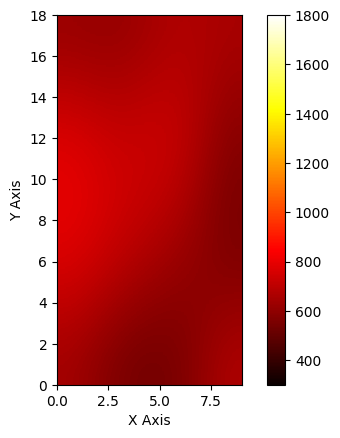

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom

# 讀取 csv 文件
file_path = '1119-1in3out-mv-mc-mid.csv'
df = pd.read_csv(file_path)

# 找到 time=110 對應的行，提取 S1 到 S16 資料
row_110 = df[df['time'] == 1000]
if not row_110.empty:
    s1_to_s16 = row_110.iloc[0, 1:17].values  # 提取 S1 到 S16 資料
    s1_to_s16 = s1_to_s16.reshape(4, 4)  # 轉換為 4x4 格式

    # 插值到 90x180
    s1_to_s16_interp = zoom(s1_to_s16, (90/4, 180/4), order=3)  # 使用三次樣條進行插值

    # 繪製影像
    plt.imshow(s1_to_s16_interp, cmap='hot', extent=[0, 9, 0, 18], vmin=300, vmax=1800)  # 自訂橫軸和縱軸範圍為 [0, 9] 和 [0, 18]
    plt.colorbar()
    plt.title('')
    plt.xlabel('X Axis')
    plt.ylabel('Y Axis')
    plt.xlim(0, 9)  # 自訂橫軸範圍
    plt.ylim(0, 18)  # 自訂縱軸範圍
    plt.show()
else:
    print("無法找到 time=110 的資料")